In [5]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
from scqubits import *
import numpy as np

In [26]:
scqubits.GUI()

Container(children=[Sheet(children=[Card(children=[Img(layout=None, src='data:image/png;base64,iVBORw0KGgoAAAA…

TypeError: '<' not supported between instances of 'float' and 'NoneType'

TypeError: '<' not supported between instances of 'float' and 'NoneType'

In [6]:
from scqubits.utils.spectrum_utils import convert_evecs_to_ndarray

def generate_single_mapping(H_with_interaction_no_drive) -> np.ndarray:
    """
    Maps product of bare states to dressed state
    Returns a dictionary like {(0,0,0):0,(0,0,1):1}
    Use this function instead of scqubit's because I can change the overlap threshold here
    """
    evals, evecs = H_with_interaction_no_drive.eigenstates()
    overlap_matrix = convert_evecs_to_ndarray(evecs)
    # OVERLAP_THRESHOLD = 0.02
    product_state_names = []
    dims = H_with_interaction_no_drive.dims[0]
    system_size = len(dims)
    def generate_product_states(current_state, ele_index):
        if ele_index == system_size:
            product_state_names.append(tuple(current_state))
            return
        
        for l in range(dims[ele_index]):
            current_state[ele_index] = l
            generate_product_states(current_state.copy(), ele_index + 1)

    current_state = [0] * system_size
    generate_product_states(current_state, 0)

    total_dim = math.prod(dims)
    dressed_indices = [None] * total_dim
    for dressed_index in range(len(evals)):
        max_position = (np.abs(overlap_matrix[dressed_index, :])).argmax()
        max_overlap = np.abs(overlap_matrix[dressed_index, max_position])
        overlap_matrix[:, max_position] = 0
        dressed_indices[int(max_position)] = dressed_index
        # if (max_overlap**2 < OVERLAP_THRESHOLD):
        #     print(f'max overlap^2 {max_overlap**2} below threshold for dressed state {dressed_index} with eval {evals[dressed_index]}')
    product_to_dressed = {}
    for product, dressed in zip(product_state_names,dressed_indices):
        product_to_dressed[product] = dressed
    return product_to_dressed

In [7]:
EC = 1.358
EL = 0.23
g = 0.3
def get_estimations(EJ, Er):
    try:
        g_strength = g
        qubit_level = 25
        osc_level =16

        qbt = Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
        q_evals = qbt.eigenvals()
        one_two_transition = q_evals[2]-q_evals[1]
        E_osc = Er
        osc = Oscillator(E_osc=E_osc,truncated_dim=osc_level)
        hilbertspace = HilbertSpace([qbt, osc])
        hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
        hilbertspace.generate_lookup()
        product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
        energies =  hilbertspace.eigenvals(qubit_level*osc_level)

        def stark(ql1,ql2,ol):
            return abs(energies[product_to_dressed[(ql2,ol)]]-energies[product_to_dressed[(ql1,ol)]])
        def lamb(ol1,ol2,ql):
            return abs(energies[product_to_dressed[(ql,ol2)]]-energies[product_to_dressed[(ql,ol1)]])
        def detuning(ql1,ql2):
            return abs((energies[product_to_dressed[(ql1,1)]]-energies[product_to_dressed[(ql1,0)]])  -
                            (energies[product_to_dressed[(ql2,1)]]-energies[product_to_dressed[(ql2,0)]]))
        
        results = (np.float16(one_two_transition),#Want it small
                np.float16(stark(1,2,0)-stark(1,2,1)),
                np.float16(stark(1,2,0)-stark(1,2,2)),# differential_stark_on_qubit_12_from_osc02 Want it small
                np.float16(abs(lamb(0,1,0)-lamb(1,2,0))), # For easy populating photons
                np.float16(abs(lamb(0,1,0)-lamb(2,3,0))),
                np.float16(abs(lamb(0,1,0)-lamb(3,4,0))),
                np.float16(abs(lamb(0,1,0)-lamb(4,5,0))),
                np.float16(abs(lamb(0,1,0)-lamb(5,6,0))),
                np.float16(abs(lamb(0,1,0)-lamb(6,7,0))),#Want it small
                np.float16(detuning(0,1)),
                np.float16(detuning(0,2)))#Want it big
        results = tuple(x if np.shape(x) == () else None for x in results)
        print('done one')
        return results

    except Exception as e:
        return (None, None, None,
                 None,None,None,
                 None,None,None,
                 None,None)

In [8]:
EJ_values = np.linspace(5,8, 50)
Er_values = np.linspace(8, 16, 50)

EJ_grid,Er_grid = np.meshgrid(EJ_values, Er_values)

EJ_flat = EJ_grid.flatten()
Er_flat = Er_grid.flatten()

results = np.vectorize(get_estimations)(EJ_flat, Er_flat)

done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
done one
d

In [12]:
EJ_subdivisions = 50
Er_subdivisions = 50
num_elements_in_result = 11 #number of values produced for one set of parameters.
shape_of_grid = (EJ_subdivisions, Er_subdivisions)
list_of_grid = [np.zeros(shape_of_grid,dtype=np.float32) for _ in range(num_elements_in_result)]
# Initialize counter for existing chunks
existing_chunk_num = 0


total_elements = EJ_subdivisions* Er_subdivisions


# Initialize flattened arrays to store the results for this EJ value
list_of_flat = [np.zeros(total_elements) for _ in range(num_elements_in_result)]

# Place the results back into the flattened arrays
for idx, element in enumerate(results):
    list_of_flat[idx] = element


# Reshape the flattened arrays back into the original grid for this EJ value
for idx, grid in enumerate(list_of_grid):
    grid[ :, :] = list_of_flat[idx].reshape(shape_of_grid)


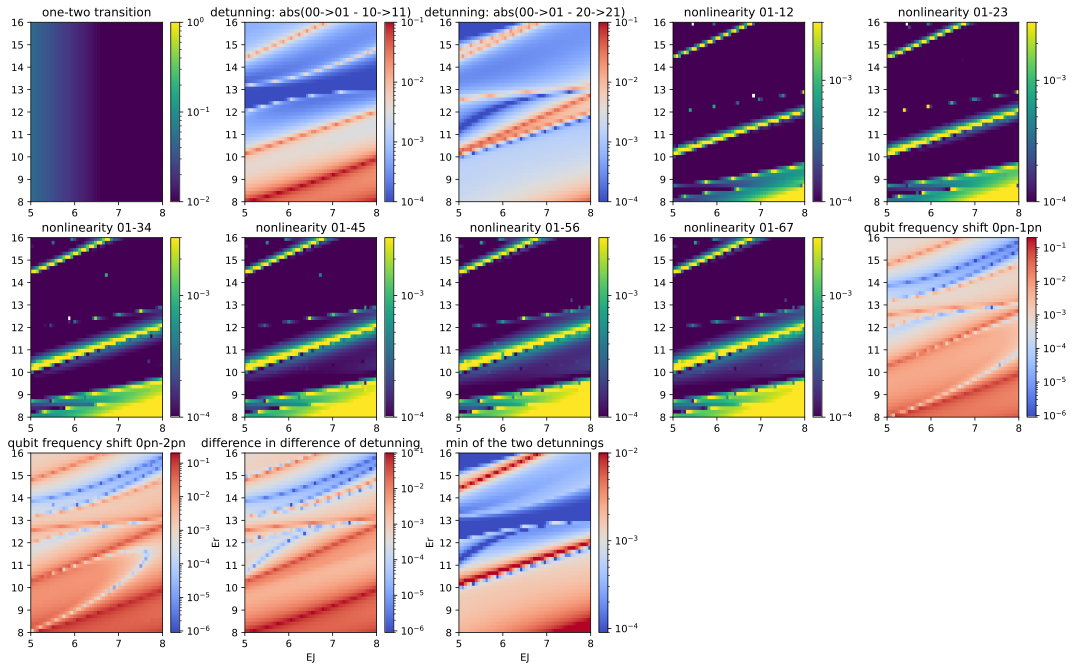

In [25]:
from matplotlib.colors import LogNorm, SymLogNorm
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import numpy as np

extent = (EJ_values[0], EJ_values[-1], Er_values[0], Er_values[-1])
plt.figure(figsize=(15, 12))

plt.subplot(4, 5, 1)
plt.imshow(list_of_grid[0][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax = 1,vmin = 1e-2))
plt.colorbar(label='')
plt.title(f'one-two transition')

plt.subplot(4, 5, 2)
plt.imshow(list_of_grid[-2][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax = 1e-1,vmin = 1e-4), cmap='coolwarm')
plt.colorbar(label='')
plt.title(f'detunning: abs(00->01 - 10->11)')

plt.subplot(4, 5, 3)
plt.imshow(list_of_grid[-1][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax = 1e-1,vmin = 1e-4), cmap='coolwarm')
plt.colorbar(label='')
plt.title(f'detunning: abs(00->01 - 20->21)')

plt.subplot(4, 5, 4)
plt.imshow(list_of_grid[3][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =3e-3,vmin = 1e-4))
plt.colorbar(label='')
plt.title(f'nonlinearity 01-12')
plt.subplot(4, 5, 5)
plt.imshow(list_of_grid[4][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =3e-3,vmin = 1e-4))
plt.colorbar(label='')
plt.title(f'nonlinearity 01-23')
plt.subplot(4, 5, 6)
plt.imshow(list_of_grid[5][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =3e-3,vmin = 1e-4))
plt.colorbar(label='')
plt.title(f'nonlinearity 01-34')
plt.subplot(4, 5, 7)
plt.imshow(list_of_grid[6][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =3e-3,vmin = 1e-4))
plt.colorbar(label='')
plt.title(f'nonlinearity 01-45')
plt.subplot(4, 5, 8)
plt.imshow(list_of_grid[7][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =3e-3,vmin = 1e-4))
plt.colorbar(label='')
plt.title(f'nonlinearity 01-56')
plt.subplot(4, 5, 9)
plt.imshow(list_of_grid[7][:,:],extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =3e-3,vmin = 1e-4))
plt.colorbar(label='')
plt.title(f'nonlinearity 01-67')

plt.subplot(4, 5, 10)
plt.imshow(abs(list_of_grid[1][:,:]),extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax = 1e-6,vmin = 2e-1), cmap='coolwarm')
plt.colorbar(label='')
plt.title(f'qubit frequency shift 0pn-1pn')

plt.subplot(4, 5, 11)
plt.imshow(abs(list_of_grid[2][:,:]),extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax = 1e-6,vmin = 2e-1), cmap='coolwarm')
plt.colorbar(label='')
plt.title(f'qubit frequency shift 0pn-2pn')

plt.subplot(4, 5, 12)
plt.imshow(abs(list_of_grid[-2][:,:]-list_of_grid[-1][:,:]),extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =  1e-6,vmin = 1e-1), cmap='coolwarm')
plt.colorbar(label='')
plt.xlabel('EJ')
plt.ylabel('Er')
plt.title(f'difference in difference of detunning')

plt.subplot(4, 5, 13)
plt.imshow(np.minimum(list_of_grid[-2][:,:], list_of_grid[-1][:,:]),extent = extent, origin='lower', aspect='auto', norm=LogNorm(vmax =  1e-4,vmin = 1e-2), cmap='coolwarm')
plt.colorbar(label='')
plt.xlabel('EJ')
plt.ylabel('Er')
plt.title(f'min of the two detunnings')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.show()